# IT Equipment — Exploratory Data Analysis (EDA)
## NALCO Internship Project
### Step 3 of 7 — Understand the data visually before building ML model

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned IT dataset
df = pd.read_csv("../data/IT_Equipment_Dataset_CLEANED.csv")
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Failure rate: {df['Failure'].mean()*100:.1f}%")
df.head()

Dataset loaded successfully!
Rows    : 2000
Columns : 40
Failure rate: 15.4%


,Device_ID,Device_Type,Location,Operating_System,Date,Shift,Device_Age_Years,CPU_Usage_pct,RAM_Usage_pct,Disk_Usage_pct,...,Shift_enc,Maintenance_Priority_enc,Operating_System_enc,CPU_RAM_Avg,Temp_Fan_Ratio,Resource_Pressure,Overdue_Maintenance,Critical_Temp,High_Error,Age_Maint_Score
0,IT-UPS-002,UPS,Power Room,Unknown,2023-02-19,Morning,2.2,9.3,30.3,16.4,...,1,2,8,19.80,16.9467,17.73,0,0,0,0.99
1,IT-WRK-003,Workstation,Office,Windows 11,2021-07-03,Night,2.0,53.7,55.5,71.8,...,2,3,10,54.60,19.4184,59.67,1,0,0,3.84
2,IT-RTR-002,Router,Network Room,Unknown,2021-11-08,Afternoon,1.8,31.3,35.4,21.8,...,0,2,8,33.35,15.0718,29.68,0,0,0,0.77
3,IT-SRV-003,Server,Data Center,Red Hat Linux,2023-08-19,Afternoon,0.8,51.5,34.4,51.3,...,0,3,5,42.95,8.7086,46.31,1,0,0,1.74
4,IT-WRK-004,Workstation,Office,Ubuntu 20.04,2021-06-15,Afternoon,7.3,16.2,66.1,52.8,...,0,0,6,41.15,24.9885,42.15,0,0,1,1.97


## Graph 1 — Failures by Device Type
**Question: Which device type fails the most?**

Graphs folder ready!


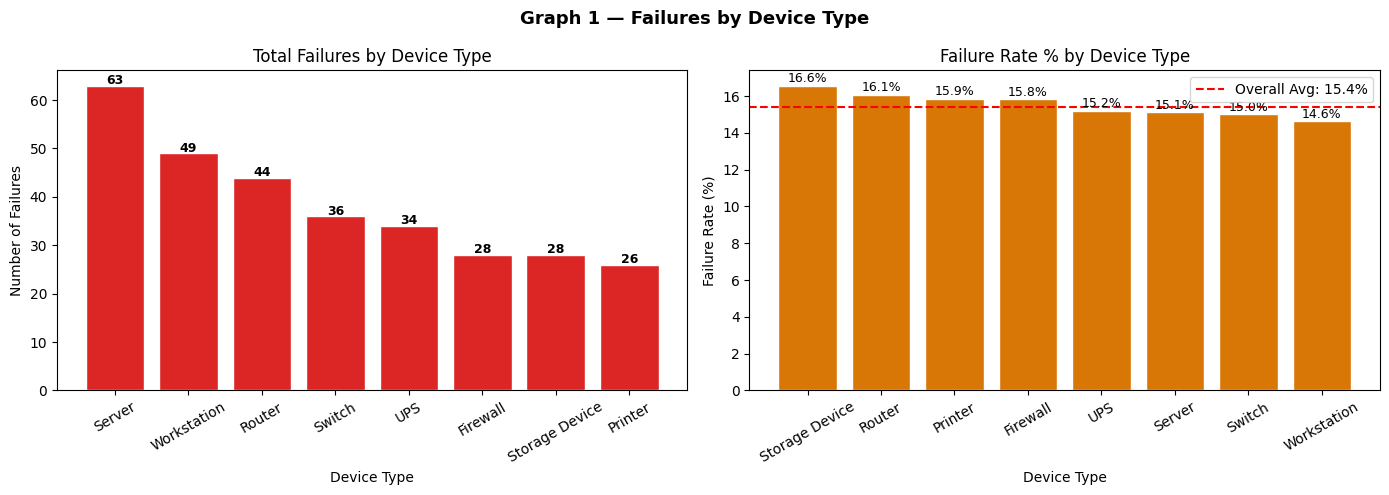

Observation: Check which device type has highest failure rate above.


In [7]:
import os

# Create graphs folder if it does not exist
os.makedirs('../graphs', exist_ok=True)

print("Graphs folder ready!")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 1 — Failures by Device Type', fontsize=13, fontweight='bold')

# Total failures
fail_count = df.groupby('Device_Type')['Failure'].sum().sort_values(ascending=False)
axes[0].bar(fail_count.index, fail_count.values, color='#DC2626', edgecolor='white')
axes[0].set_title('Total Failures by Device Type')
axes[0].set_xlabel('Device Type'); axes[0].set_ylabel('Number of Failures')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(fail_count.values):
    axes[0].text(i, v+0.3, str(v), ha='center', fontsize=9, fontweight='bold')

# Failure rate
fail_rate = df.groupby('Device_Type')['Failure'].mean().mul(100).sort_values(ascending=False)
axes[1].bar(fail_rate.index, fail_rate.values, color='#D97706', edgecolor='white')
axes[1].set_title('Failure Rate % by Device Type')
axes[1].set_xlabel('Device Type'); axes[1].set_ylabel('Failure Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(df['Failure'].mean()*100, color='red', linestyle='--',
                label=f'Overall Avg: {df["Failure"].mean()*100:.1f}%')
axes[1].legend()
for i, v in enumerate(fail_rate.values):
    axes[1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../graphs/IT_G1_failure_by_device_type.png', dpi=120, bbox_inches='tight')
plt.show()
print("Observation: Check which device type has highest failure rate above.")

## Graph 2 — Temperature vs Failure
**Question: Is temperature higher in failed devices?**

Normal avg temperature : 37.6 C
Failure avg temperature: 46.9 C
Difference             : 9.3 C higher in failed devices


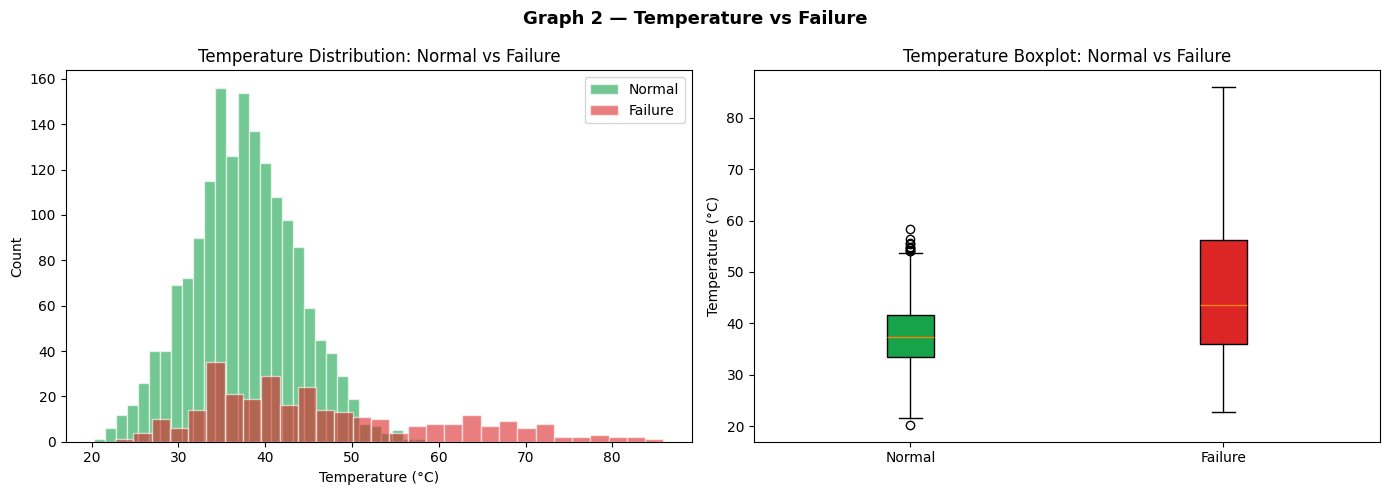

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 2 — Temperature vs Failure', fontsize=13, fontweight='bold')

for val, label, color in [(0,'Normal','#16A34A'), (1,'Failure','#DC2626')]:
    axes[0].hist(df[df['Failure']==val]['Temperature_C'],
                 bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Temperature Distribution: Normal vs Failure')
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('Count')
axes[0].legend()

bp = axes[1].boxplot(
    [df[df['Failure']==0]['Temperature_C'], df[df['Failure']==1]['Temperature_C']],
    labels=['Normal','Failure'], patch_artist=True)
bp['boxes'][0].set_facecolor('#16A34A'); bp['boxes'][1].set_facecolor('#DC2626')
axes[1].set_title('Temperature Boxplot: Normal vs Failure')
axes[1].set_ylabel('Temperature (°C)')

normal_avg = df[df['Failure']==0]['Temperature_C'].mean()
fail_avg   = df[df['Failure']==1]['Temperature_C'].mean()
print(f"Normal avg temperature : {normal_avg:.1f} C")
print(f"Failure avg temperature: {fail_avg:.1f} C")
print(f"Difference             : {fail_avg - normal_avg:.1f} C higher in failed devices")

plt.tight_layout()
plt.savefig('../graphs/IT_G2_temperature_vs_failure.png', dpi=120, bbox_inches='tight')
plt.show()

## Graph 3 — CPU, RAM, Disk Usage vs Failure
**Question: Does high resource usage cause failure?**

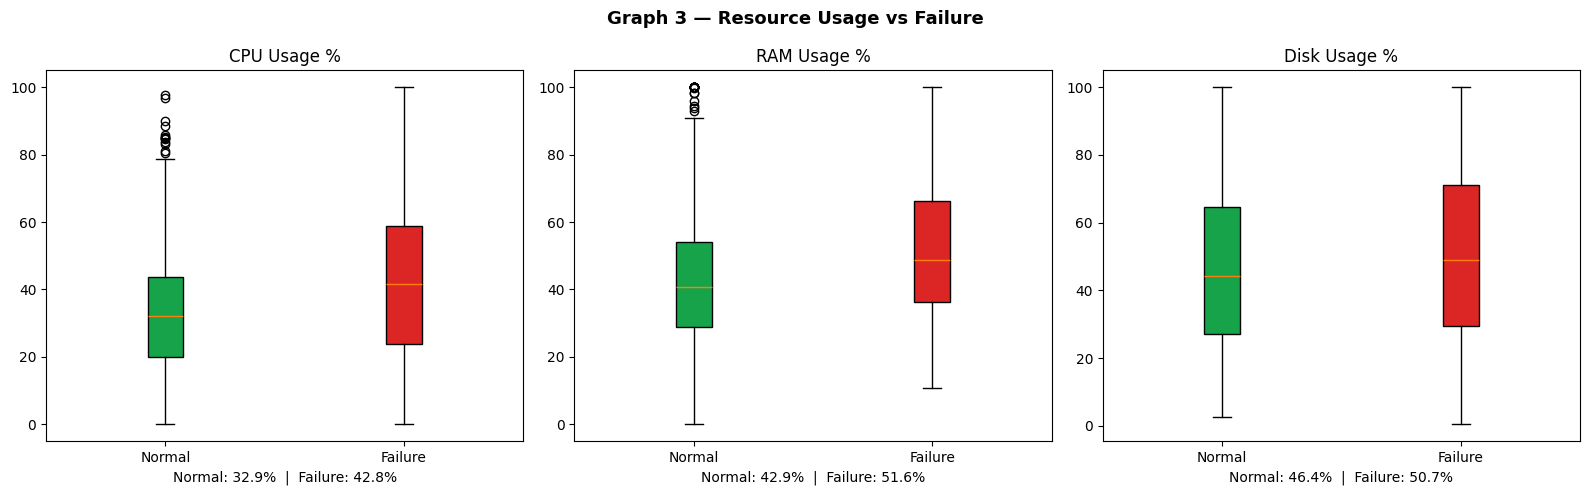

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Graph 3 — Resource Usage vs Failure', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
    ['CPU_Usage_pct', 'RAM_Usage_pct', 'Disk_Usage_pct'],
    ['CPU Usage %', 'RAM Usage %', 'Disk Usage %']):
    bp = ax.boxplot(
        [df[df['Failure']==0][col], df[df['Failure']==1][col]],
        labels=['Normal','Failure'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#16A34A')
    bp['boxes'][1].set_facecolor('#DC2626')
    ax.set_title(title)
    n_avg = df[df['Failure']==0][col].mean()
    f_avg = df[df['Failure']==1][col].mean()
    ax.set_xlabel(f'Normal: {n_avg:.1f}%  |  Failure: {f_avg:.1f}%')

plt.tight_layout()
plt.savefig('../graphs/IT_G3_resource_usage_vs_failure.png', dpi=120, bbox_inches='tight')
plt.show()

## Graph 4 — Failure Types & Components
**Question: Which type of failure happens most often?**

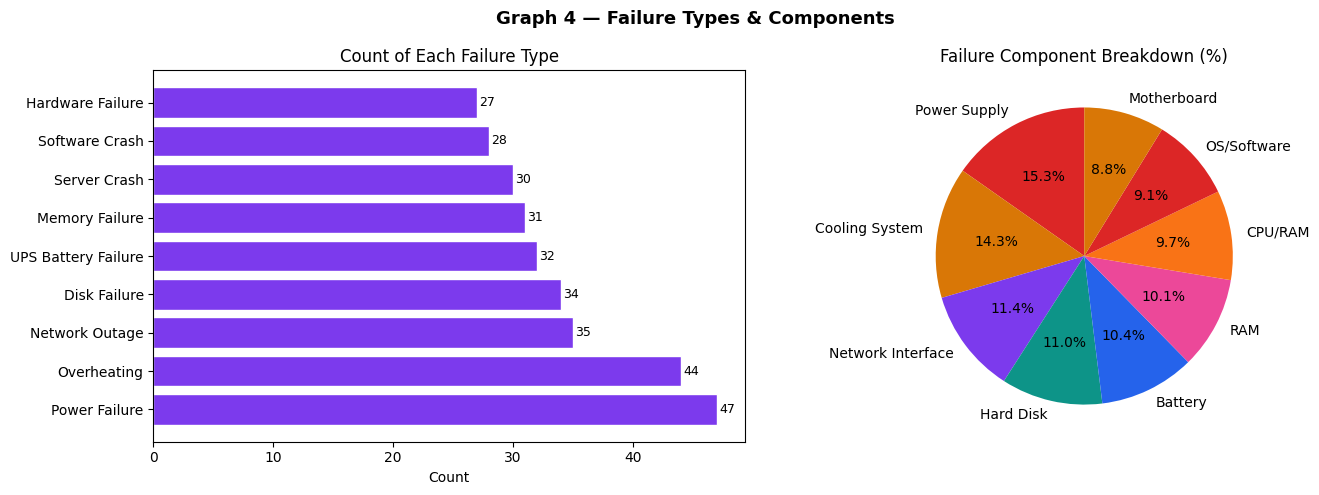

Most common failure: Power Failure (47 times)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 4 — Failure Types & Components', fontsize=13, fontweight='bold')

failed_df = df[df['Failure'] == 1]

fail_types = failed_df['Failure_Type'].value_counts()
axes[0].barh(fail_types.index, fail_types.values, color='#7C3AED', edgecolor='white')
axes[0].set_title('Count of Each Failure Type')
axes[0].set_xlabel('Count')
for i, v in enumerate(fail_types.values):
    axes[0].text(v+0.2, i, str(v), va='center', fontsize=9)

fail_comp = failed_df['Failure_Component'].value_counts()
colors_pie = ['#DC2626','#D97706','#7C3AED','#0D9488','#2563EB','#EC4899','#F97316']
axes[1].pie(fail_comp.values, labels=fail_comp.index,
            autopct='%1.1f%%', colors=colors_pie[:len(fail_comp)], startangle=90)
axes[1].set_title('Failure Component Breakdown (%)')

plt.tight_layout()
plt.savefig('../graphs/IT_G4_failure_types.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Most common failure: {fail_types.index[0]} ({fail_types.values[0]} times)")

## Graph 5 — Correlation Heatmap
**Question: Which features are most related to failure?**

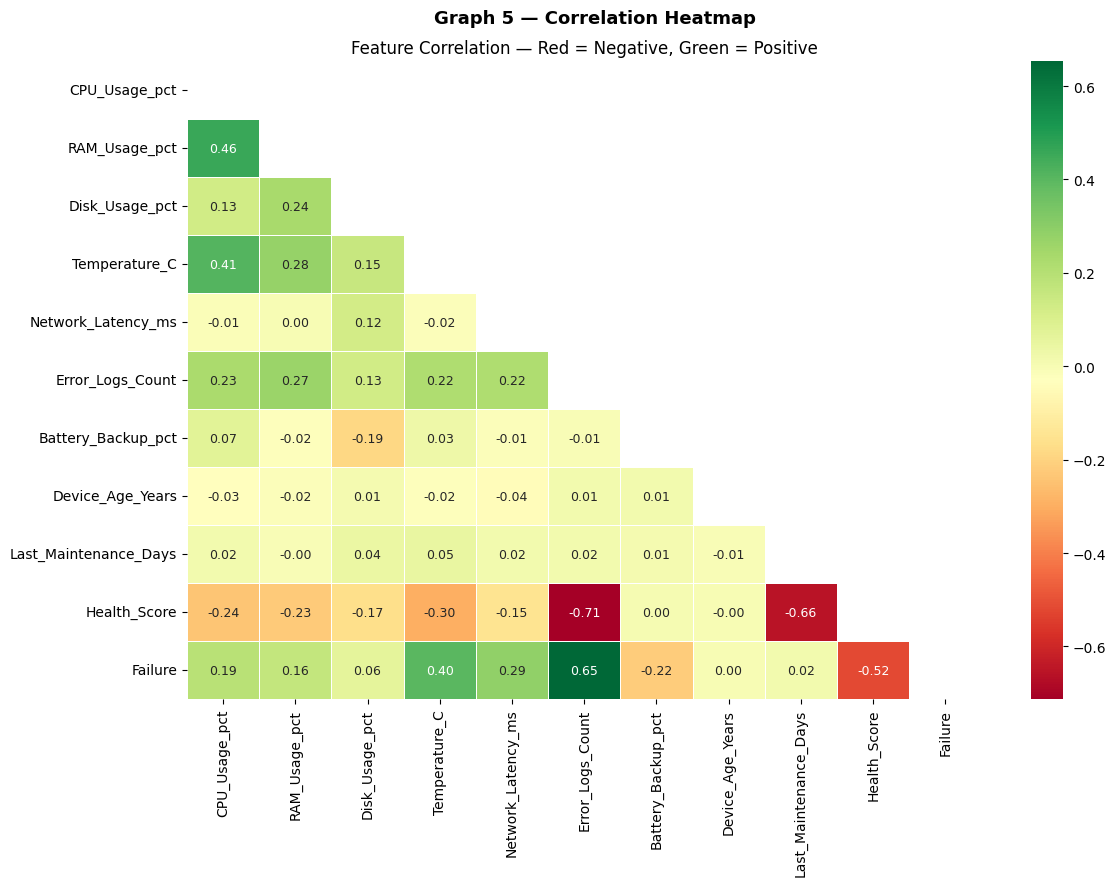

Top features correlated with Failure:
Error_Logs_Count      0.652999
Health_Score          0.519141
Temperature_C         0.398547
Network_Latency_ms    0.288120
Battery_Backup_pct    0.218419
Name: Failure, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Graph 5 — Correlation Heatmap', fontsize=13, fontweight='bold')

num_cols = ['CPU_Usage_pct','RAM_Usage_pct','Disk_Usage_pct',
            'Temperature_C','Network_Latency_ms','Error_Logs_Count',
            'Battery_Backup_pct','Device_Age_Years',
            'Last_Maintenance_Days','Health_Score','Failure']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Feature Correlation — Red = Negative, Green = Positive')

plt.tight_layout()
plt.savefig('../graphs/IT_G5_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Print top correlations with Failure
print("Top features correlated with Failure:")
print(corr['Failure'].drop('Failure').abs().sort_values(ascending=False).head(5))

## Graph 6 — Health Score & Maintenance Priority
**Question: How healthy are devices and how urgent is maintenance?**

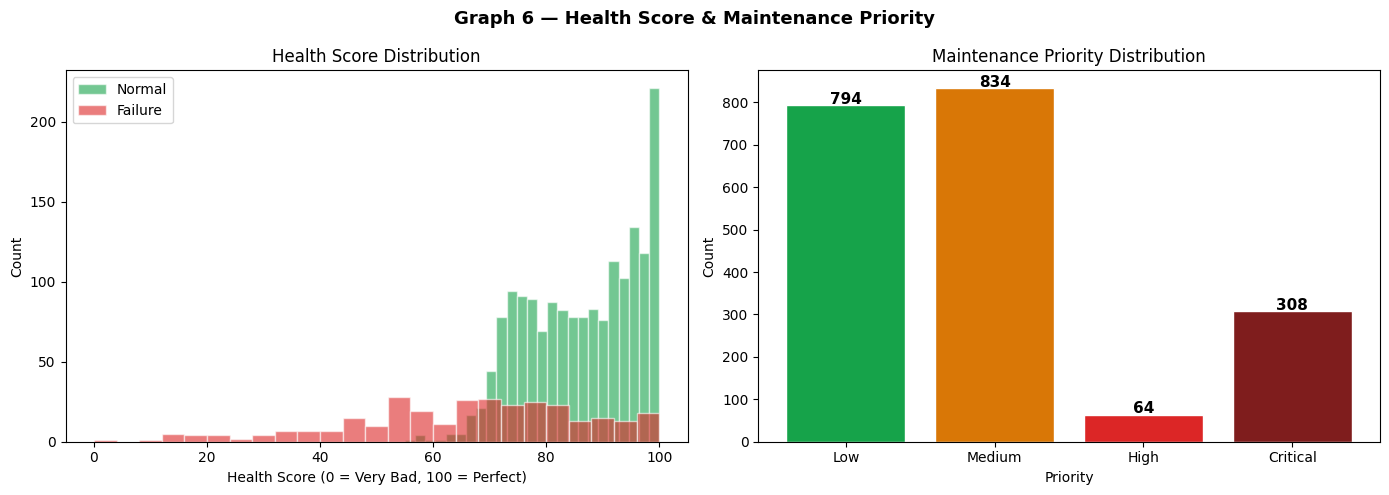

Critical devices needing immediate attention: 308


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 6 — Health Score & Maintenance Priority', fontsize=13, fontweight='bold')

for val, label, color in [(0,'Normal','#16A34A'), (1,'Failure','#DC2626')]:
    axes[0].hist(df[df['Failure']==val]['Health_Score'],
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Health Score Distribution')
axes[0].set_xlabel('Health Score (0 = Very Bad, 100 = Perfect)')
axes[0].set_ylabel('Count'); axes[0].legend()

mp = df['Maintenance_Priority'].value_counts().reindex(
     ['Low','Medium','High','Critical'], fill_value=0)
axes[1].bar(mp.index, mp.values,
            color=['#16A34A','#D97706','#DC2626','#7F1D1D'], edgecolor='white')
axes[1].set_title('Maintenance Priority Distribution')
axes[1].set_xlabel('Priority'); axes[1].set_ylabel('Count')
for i, v in enumerate(mp.values):
    axes[1].text(i, v+3, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../graphs/IT_G6_health_maintenance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Critical devices needing immediate attention: {mp.get('Critical', 0)}")

## Graph 7 — Error Logs & Device Age
**Question: Do older devices with more errors fail more?**

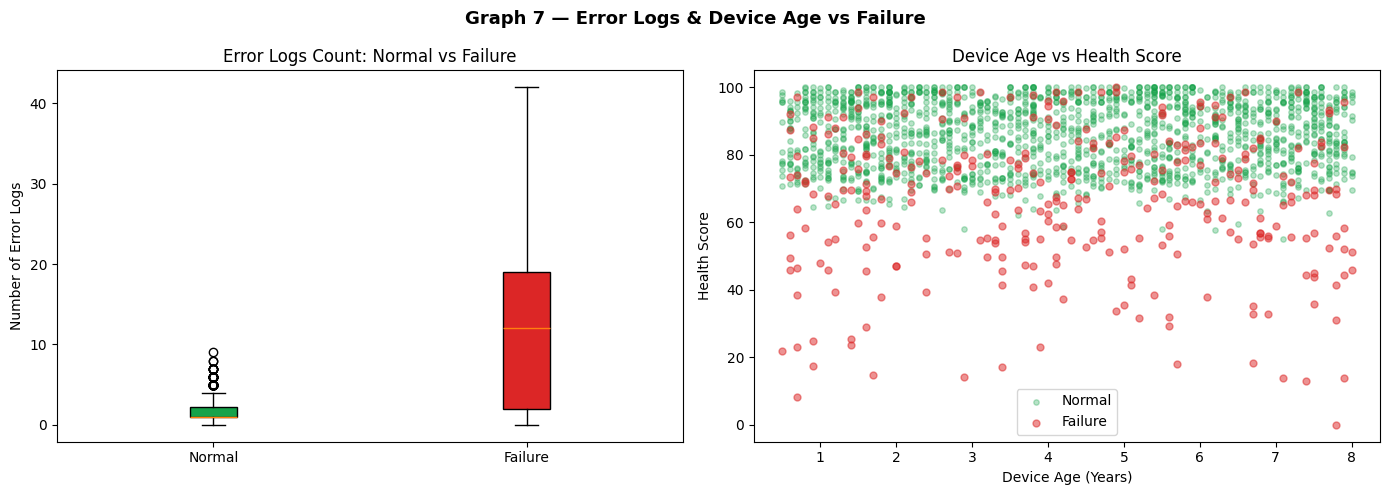

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 7 — Error Logs & Device Age vs Failure', fontsize=13, fontweight='bold')

bp = axes[0].boxplot(
    [df[df['Failure']==0]['Error_Logs_Count'],
     df[df['Failure']==1]['Error_Logs_Count']],
    labels=['Normal','Failure'], patch_artist=True)
bp['boxes'][0].set_facecolor('#16A34A'); bp['boxes'][1].set_facecolor('#DC2626')
axes[0].set_title('Error Logs Count: Normal vs Failure')
axes[0].set_ylabel('Number of Error Logs')

axes[1].scatter(df[df['Failure']==0]['Device_Age_Years'],
                df[df['Failure']==0]['Health_Score'],
                alpha=0.3, color='#16A34A', s=15, label='Normal')
axes[1].scatter(df[df['Failure']==1]['Device_Age_Years'],
                df[df['Failure']==1]['Health_Score'],
                alpha=0.5, color='#DC2626', s=25, label='Failure')
axes[1].set_title('Device Age vs Health Score')
axes[1].set_xlabel('Device Age (Years)'); axes[1].set_ylabel('Health Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../graphs/IT_G7_error_logs_age.png', dpi=120, bbox_inches='tight')
plt.show()

## Graph 8 — Monthly Trend & Maintenance Priority Failure Rate
**Question: Is failure increasing over time? Which priority level fails most?**

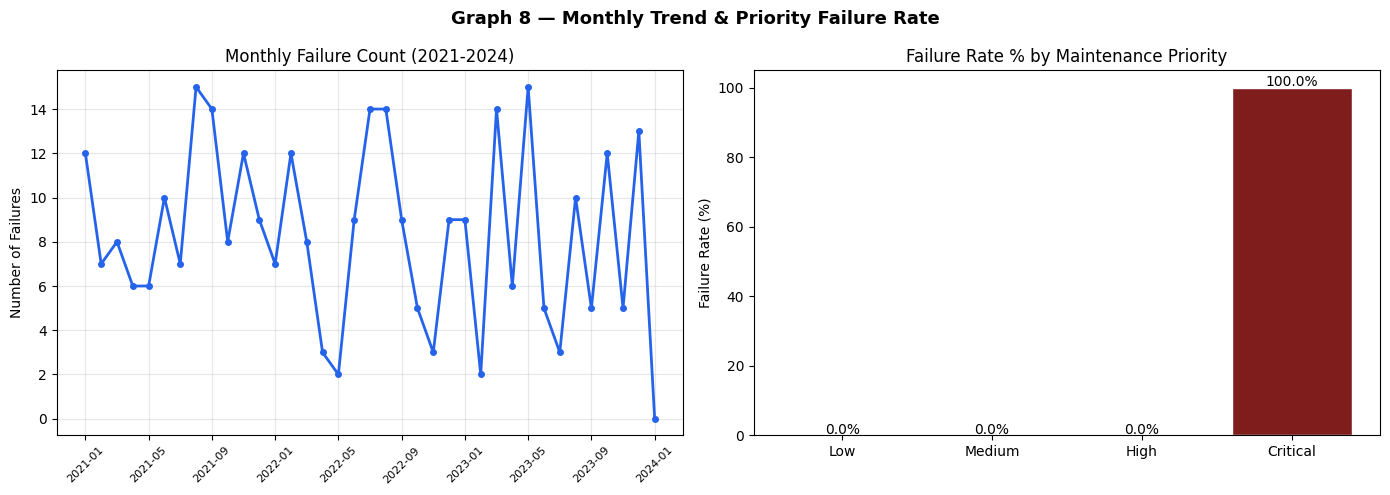

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Graph 8 — Monthly Trend & Priority Failure Rate', fontsize=13, fontweight='bold')

monthly = df.groupby(['Year','Month'])['Failure'].sum().reset_index()
monthly['Period'] = (monthly['Year'].astype(str) + '-' +
                     monthly['Month'].astype(str).str.zfill(2))
axes[0].plot(range(len(monthly)), monthly['Failure'],
             color='#2563EB', marker='o', markersize=4, linewidth=2)
step = max(1, len(monthly)//8)
axes[0].set_xticks(range(0, len(monthly), step))
axes[0].set_xticklabels(monthly['Period'].iloc[::step], rotation=45, fontsize=8)
axes[0].set_title('Monthly Failure Count (2021-2024)')
axes[0].set_ylabel('Number of Failures'); axes[0].grid(True, alpha=0.3)

mp_fail = (df.groupby('Maintenance_Priority')['Failure']
             .mean().mul(100)
             .reindex(['Low','Medium','High','Critical']))
axes[1].bar(mp_fail.index, mp_fail.values,
            color=['#16A34A','#D97706','#DC2626','#7F1D1D'], edgecolor='white')
axes[1].set_title('Failure Rate % by Maintenance Priority')
axes[1].set_ylabel('Failure Rate (%)')
for i, v in enumerate(mp_fail.values):
    axes[1].text(i, v+0.4, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../graphs/IT_G8_trend_priority.png', dpi=120, bbox_inches='tight')
plt.show()

## EDA Summary
**Key findings from IT Equipment EDA:**

In [15]:
print("="*55)
print("IT EQUIPMENT EDA — KEY FINDINGS SUMMARY")
print("="*55)
print(f"Total Records         : {len(df)}")
print(f"Total Failures        : {df['Failure'].sum()}")
print(f"Overall Failure Rate  : {df['Failure'].mean()*100:.1f}%")
print()
print("Most failing device type:")
print(f"  {df.groupby('Device_Type')['Failure'].sum().idxmax()}")
print()
print("Most common failure type:")
print(f"  {df[df['Failure']==1]['Failure_Type'].value_counts().index[0]}")
print()
print("Average temperature — Normal vs Failure:")
print(f"  Normal : {df[df['Failure']==0]['Temperature_C'].mean():.1f} C")
print(f"  Failure: {df[df['Failure']==1]['Temperature_C'].mean():.1f} C")
print()
print("Critical devices needing immediate attention:")
print(f"  {(df['Maintenance_Priority']=='Critical').sum()} devices")
print()
print("Top 3 features correlated with Failure:")
num_c = ['CPU_Usage_pct','RAM_Usage_pct','Disk_Usage_pct',
         'Temperature_C','Error_Logs_Count','Health_Score',
         'Device_Age_Years','Last_Maintenance_Days']
top3 = df[num_c+['Failure']].corr()['Failure'].drop('Failure').abs().nlargest(3)
for feat, val in top3.items():
    print(f"  {feat}: {val:.3f}")
print()
print("EDA Complete! Ready for ML Model building.")

IT EQUIPMENT EDA — KEY FINDINGS SUMMARY
Total Records         : 2000
Total Failures        : 308
Overall Failure Rate  : 15.4%

Most failing device type:
  Server

Most common failure type:
  Power Failure

Average temperature — Normal vs Failure:
  Normal : 37.6 C
  Failure: 46.9 C

Critical devices needing immediate attention:
  308 devices

Top 3 features correlated with Failure:
  Error_Logs_Count: 0.653
  Health_Score: 0.519
  Temperature_C: 0.399

EDA Complete! Ready for ML Model building.
